In [1]:

from pathlib import Path
import time
import numpy as np
from astropy.cosmology import Planck18 as cosmo
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad, simps, cumtrapz  # ADD cumtrapz HERE
from scipy.optimize import curve_fit
from scipy.special import erf
import sympy as sp
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches
from astropy.cosmology import Planck18 as cosmo, z_at_value
from astropy import units as u
from scipy.interpolate import interp1d
from astropy.cosmology import FlatLambdaCDM

In [2]:
# ============================================================================
# TELESCOPE SELECTION
# ============================================================================
TELESCOPE = "D0"
# Other options: "Fast", "Meerkat_incoherent", "Meerkat_coherent", "askap_ics", "askap_flyeye"

TELESCOPE_PARAMS = {


    "d0": {
        "D":12,
        "eta": 0.6,
        "Trec": 22,
        "Tsky": 3,
        "BW": 300e6,
        "nu_cen": 1.4e9,
        "n_comp": 16,
        "n_chan": 2048,
        "tsamp": 1.e-3,

    },

    "5d0": {
        "D":5*12,
        "eta": 0.6,
        "Trec": 22,
        "Tsky": 3,
        "BW": 300e6,
        "nu_cen": 1.4e9,
        "n_comp": 16,
        "n_chan": 1024,
        "tsamp": 1.e-3,

    },

    "25d0": {
        "D":25*12,
        "eta": 0.6,
        "Trec": 22,
        "Tsky": 3,
        "BW": 300e6,
        "nu_cen": 1.4e9,
        "n_comp": 16,
        "n_chan": 1024,
        "tsamp": 1.e-3,

    }
}


In [3]:
alpha_intrinsic = -2  # Fixed intrinsic spectral index

In [4]:

# EFFECT CONTROL FLAGS
# ============================================================================
USE_COSMOLOGY = True      # Tozggle Euclidean vs cosmological universe (affects distances, volumes)
USE_SFR = True           
USE_SMEARING = True      
USE_SPECTRAL_INDEX = True 


# USE_COSMOLOGY = False
# USE_SFR = False           
# USE_SMEARING = False    
# USE_SPECTRAL_INDEX = False

USE_BEAM = True
# USE_BEAM = False

# # Luminosity function parameters
LUMINOSITY_FUNCTION = "schechter"  
# LUMINOSITY_FUNCTION = "std" 

In [5]:


# Load selected telescope
if TELESCOPE.lower() not in TELESCOPE_PARAMS:
    raise ValueError(f"Telescope must be one of: {list(TELESCOPE_PARAMS.keys())}")

params = TELESCOPE_PARAMS[TELESCOPE.lower()]

# Physical constants
k = 1.38e-23
c = 3.0e8

# Extract telescope parameters
D = params["D"]
eta = params["eta"]
# n_dishes = params.get("n_dishes", 1)
# mode = params.get("mode", "single")

# n_beams = params.get("n_beams", 1) if mode != "coherent" and mode != "incoherent" else 1
# array_gain_factor = n_dishes if mode == "coherent" else np.sqrt(n_dishes) if mode == "incoherent" else 1
G0 = np.pi * D*D/4 * eta/2.0/k*1e-26
Np = 2
Trec = params["Trec"]
Tsky = params["Tsky"]
BW = params["BW"]
n_comp = params["n_comp"]
BW_comp = BW / n_comp
n_chan = params["n_chan"]
BW_chan = BW / n_chan
nu_cen = params["nu_cen"]
nu_min = nu_cen - BW / 2
nu_max = nu_cen + BW / 2
nu_array = np.linspace(nu_min, nu_max, n_comp+1)

print(f"{'='*100}")
print(f"TELESCOPE: {TELESCOPE}")
print(f"  Diameter: {D} m")
print(f"  Receiver temp: {Trec} K")
print(f"  Bandwidth: {BW/1e6:.0f} MHz at {nu_cen/1e9:.3f} GHz")
# print(f"  N_dishes: {n_dishes}, Mode: {mode}")
# print(f"  FoV: {params['fov']} deg²")
print(f"{'='*100}\n")


TELESCOPE: D0
  Diameter: 12 m
  Receiver temp: 22 K
  Bandwidth: 300 MHz at 1.400 GHz



In [6]:
# ============================================================================
# REDSHIFT PARAMETERS
# ============================================================================
dz = 0.01
z_min = 0.01
z_max = 5.0
z_array_opt = np.arange(z_min, z_max, dz)

# Options: "schechter" or "std"

L_STAR = 1e15  # Characteristic luminosity (Jy·kpc²)
ALPHA_SCH = -1.5  # Faint-end slope
L_MIN_SCH = 1e10
L_MAX_SCH = 1e16

L_std = 2.4e14  # Jy·kpc²

# Simulation parameters
theta_max = 2*1.22*c/D/nu_min # please note here
fscale = 0.2 * 1e-7  # FRB rate scaling factor

SNR_threshold = 10
t_obs = 0.001
TARGET_DETECTIONS = 10  # Target 10 detections per z-bin

# Cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

fwhm_rad = 1.22 * (c / nu_min) / D
fwhm_deg = fwhm_rad * (180 / np.pi)
r_deg = 2.0 * fwhm_deg
area = np.pi * (r_deg)**2
# area = params['fov']  # Area of sky in square degrees

# Calculate frequency-dependent scattering term
freq_powers_scatter = np.array([(nu_min * BW_comp * (i+1))**(-4) for i in range(n_comp)])

np.random.seed(42)


In [7]:
def gaussian_beam_gain(nu, G0, theta, D, c):
    """
    Gaussian beam gain with frequency dependence
    G(ν) = G₀ × exp[−θ²ν²D²×2.355²/(2×1.22²×c²)]
    """
    # Exponent coefficient
    coeff = (theta**2 * D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    return G0 * np.exp(-coeff * nu**2)

# Pre-calculate constants for speed
_COEFF_CONST = (2.355**2) / (2 * 1.22**2 * (3.0e8**2))

def gaussian_beam_gain_fast(nu_array, G0, theta, D):
    """Optimized version for the inner loop"""
    coeff = theta**2 * D**2 * _COEFF_CONST
    return G0 * np.exp(-coeff * nu_array**2)

def tophat_beam_gain(nu, G0, theta, theta_max):
    """Tophat beam: constant G0 within theta_max/2, zero outside."""
    gain = G0 if theta <= (theta_max / 2) else 0.0
    return np.full_like(nu, gain, dtype=float) if np.ndim(nu) else float(gain)

def SNR(S,t,G,BW,Np,Trec,Tsky):
    return(S*G*np.sqrt(BW*t*Np)/(Trec+Tsky))

In [8]:
def schechter_function(L, L_star, alpha, phi_star=1.0):
    """
    Schechter luminosity function.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Parameters:
    -----------
    L : float or array
        Luminosity
    L_star : float
        Characteristic luminosity (knee of the function)
    alpha : float
        Faint-end slope (typically negative)
    phi_star : float
        Normalization constant (default: 1.0)
    
    Returns:
    --------
    phi : float or array
        Number density at luminosity L
    """
    x = L / L_star
    return phi_star * x**alpha * np.exp(-x)

In [9]:
def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    # REMOVE THIS LINE:
    # from scipy.integrate import cumtrapz
    
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

In [10]:

# ============================================================================
# CREATE TRUNCATED SCHECHTER SAMPLER FOR EACH Z
# ============================================================================
print("Creating truncated Schechter samplers...")

def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    from scipy.integrate import cumtrapz
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

sampler_cache = {}
print(f"  Done!\n")

def std_sampler(L_candle):
    """Return a fixed luminosity sampler for standard candle model"""
    def sampler(u):
        return L_candle
    return sampler

Creating truncated Schechter samplers...
  Done!



In [11]:
# ============================================================================
# MULTI-TELESCOPE COMPARISON: RUN ALL 3 TELESCOPES AND PLOT TOGETHER
# ============================================================================

print("\n" + "="*100)
print("RUNNING 3-TELESCOPE COMPARISON")
print("="*100 + "\n")

# Store results for each telescope
all_results = {}
colors_tel = {
    "d0": "#1f77b4",      # blue
    "5d0": "#ff7f0e",     # orange
    "25d0": "#2ca02c"     # green
}
labels_tel = {
    "d0": "D0 - 12m",
    "5d0": "5D0 - 60m",
    "25d0": "25D0 - 300m"
}

# Save original telescope parameters
D_orig = D
G0_orig = G0
theta_max_orig = theta_max
params_orig = params.copy()

# Define once for the Euclidean branch
H0_km_s_Mpc = cosmo.H0.value if hasattr(cosmo, "H0") else 70.0
DH_Mpc = 299792.458 / H0_km_s_Mpc

# Loop through all telescopes
for tel_key in ["d0", "5d0", "25d0"]:
    print(f"\n{'='*60}")
    print(f"TELESCOPE: {labels_tel[tel_key]}")
    print(f"{'='*60}")

    # Update telescope parameters
    params = TELESCOPE_PARAMS[tel_key]
    D = params["D"]
    G0 = np.pi * D * D / 4 * eta / 2.0 / k * 1e-26
    theta_max = 2 * 1.22 * c / D / nu_min

    # Recalculate area for this telescope
    fwhm_rad = 1.22 * (c / nu_min) / D
    fwhm_deg = fwhm_rad * (180 / np.pi)
    r_deg = 2.0 * fwhm_deg
    area_tel = np.pi * (r_deg)**2

    print(f"  Diameter: {D} m, G0: {G0:.4e}, theta_max: {theta_max:.6f}")
    print(f"  Sky area: {area_tel:.4f} deg²")

    # Independent seed for repeatability
    np.random.seed(42)

    # Re-compute L_min_by_z for this telescope
    L_min_by_z_new = {}
    nu0 = nu_cen

    for z in z_array_opt:
        if USE_COSMOLOGY:
            dl = cosmo.luminosity_distance(z).value * 1000.0   # kpc
        else:
            dl = (DH_Mpc * z) * 1000.0                          # kpc

        G_max = gaussian_beam_gain(nu0, G0, 0, D, 3.0e8)
        S_min = SNR_threshold * (Trec + Tsky) / (G_max * np.sqrt(BW * t_obs * Np))
        print (S_min)
        if USE_SPECTRAL_INDEX:
            z_factor = (1 + z)**(-1 - alpha_intrinsic)
        else:
            z_factor = 1.0

        L_min = S_min * (dl**2) * z_factor
        L_min_by_z_new[z] = np.clip(L_min, L_MIN_SCH, L_MAX_SCH)

    sampler_cache.clear()

    # Run simulation for this telescope
    results_tel = []
    _INNER_COEFF_CONST_new = (D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    S_SNR_CONST = np.sqrt(BW_comp * t_obs * Np) / (Trec + Tsky)

    if USE_SPECTRAL_INDEX:
        nu_scaling = (nu_array / nu0)**alpha_intrinsic
    else:
        nu_scaling = np.ones_like(nu_array)

    for z_idx, z in enumerate(z_array_opt):
        zmin = z - 0.5 * dz
        zmax = z + 0.5 * dz
        L_min_z = L_min_by_z_new[z]

        if LUMINOSITY_FUNCTION.lower() == "std":
            if L_min_z > L_std:
                break
        else:
            if L_min_z > 8.952e15:
                break

        if LUMINOSITY_FUNCTION.lower() == "std":
            truncated_sampler = std_sampler(L_std)
        else:
            if L_min_z not in sampler_cache:
                sampler_cache[L_min_z] = create_truncated_schechter_sampler(
                    L_min_z, L_MAX_SCH, L_STAR, ALPHA_SCH
                )
            truncated_sampler = sampler_cache[L_min_z]

        DM = 1000 * z
        wi_z = 0.001 * (1 + z)
        BW_chan_MHz = BW_chan / 1e6
        nu_cen_GHz = nu_cen / 1e9

        if USE_SMEARING:
            w_DM = 8.3e-6 * DM * BW_chan_MHz / (nu_cen_GHz**3)
            w_scatter_comp = (
                1.9e-7 * (DM**1.5) * (1 + (DM**3) * 3.55e-5) * 3 * freq_powers_scatter * 1e-3
            )
            w_scatter = np.sqrt(np.sum(w_scatter_comp**2) / len(w_scatter_comp))
            w_sampling = params["tsamp"] * 1e-3
        else:
            w_DM = 0.0
            w_scatter = 0.0
            w_sampling = 0.0

        w_obs_factor = np.sqrt(wi_z**2 + w_DM**2 + w_scatter**2 + w_sampling**2)

        if USE_COSMOLOGY:
            dl = cosmo.luminosity_distance(z).value * 1000.0
        else:
            dl = (DH_Mpc * z) * 1000.0

        if USE_SPECTRAL_INDEX:
            z_factor = (1 + z)**(-1 - alpha_intrinsic)
        else:
            z_factor = 1.0

        theta_hp = np.sqrt(np.log(2) / (_INNER_COEFF_CONST_new * nu0**2))

        n_generated = 0
        n_detected = 0
        detected_luminosities = []
        detected_snrs = []
        max_iterations = 1000000

        while n_detected < TARGET_DETECTIONS and n_generated < max_iterations:
            n_generated += 1
            theta_frb = theta_max * np.sqrt(np.random.random())

            if theta_frb > 4.0 * theta_hp:
                continue

            lum = float(truncated_sampler(np.random.uniform(0, 1)))
            S0_frb = (lum / (dl**2 * z_factor)) * (wi_z / w_obs_factor)
            S_nu = S0_frb * nu_scaling

            if USE_BEAM:
                G_nu = G0 * np.exp(-(_INNER_COEFF_CONST_new * theta_frb**2) * nu_array**2)
            else:
                G_nu = G0 * np.exp(-(_INNER_COEFF_CONST_new * 0.0**2) * nu_array**2)

            snr_spectrum = S_nu * G_nu * S_SNR_CONST
            snr_coherent = np.sum(snr_spectrum) / np.sqrt(n_comp)

            if snr_coherent > SNR_threshold:
                n_detected += 1
                detected_luminosities.append(lum)
                detected_snrs.append(snr_coherent)

        if n_detected == TARGET_DETECTIONS:
            detection_rate = n_detected / n_generated

            if LUMINOSITY_FUNCTION.lower() == "std":
                N_ratio = 1.0 if L_std >= L_min_z else 0.0
            else:
                L_grid_full = np.logspace(10, 16, 5000)
                phi_grid_full = schechter_function(L_grid_full, L_STAR, ALPHA_SCH)
                cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0)
                cdf_full /= cdf_full[-1]
                cdf_interp = interp1d(L_grid_full, cdf_full, kind="linear")
                N_ratio = 1.0 - cdf_interp(L_min_z)

            if USE_COSMOLOGY:
                dt = (cosmo.age(zmin).value - cosmo.age(zmax).value) * 1e9
                dvol = (
                    cosmo.comoving_volume(zmax).value - cosmo.comoving_volume(zmin).value
                ) * (area_tel / (4.0 * np.pi * ((180.0 / np.pi)**2)))
            else:
                r_Mpc = DH_Mpc * z
                dr_Mpc = DH_Mpc * dz
                area_sr = area_tel * (np.pi / 180.0)**2
                dvol = (r_Mpc**2) * dr_Mpc * area_sr
                dr_m = dr_Mpc * 3.0857e22
                dt = dr_m / c / (3600.0 * 24.0 * 365.0)

            if USE_SFR:
                psi = 0.015 * ((1 + z)**2.7) / (1 + ((1 + z) / 2.9)**5.6)
            else:
                psi = 0.015

            nfrb_sfr = psi * dvol * dt * fscale
            n_total_population = detection_rate * N_ratio * nfrb_sfr

            results_tel.append({
                "z": z,
                "DM": DM,
                "n_total_population": n_total_population
            })

            if z_idx % 50 == 0:
                print(f"  z={z:.2f}: Pop {n_total_population:.1f}")

    print(f"  ✓ Results: {len(results_tel)} redshift bins")
    all_results[tel_key] = results_tel

# Restore original parameters
params = params_orig
theta_max = theta_max_orig
G0 = G0_orig
D = D_orig

print(f"\n{'='*100}")
print("CREATING COMBINED HISTOGRAM PLOT")
print(f"{'='*100}\n")


RUNNING 3-TELESCOPE COMPARISON


TELESCOPE: D0 - 12m
  Diameter: 12 m, G0: 2.4586e-02, theta_max: 0.048800
  Sky area: 24.5604 deg²
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875
13.1271316790875


/tmp/ipykernel_1727379/4221973470.py:12: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf = cumtrapz(phi_grid, L_grid, initial=0)
/tmp/ipykernel_1727379/3771579241.py:179: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0)


  z=1.01: Pop 0.6
  z=1.51: Pop 0.0
  ✓ Results: 196 redshift bins

TELESCOPE: 5D0 - 60m
  Diameter: 60 m, G0: 6.1466e-01, theta_max: 0.009760
  Sky area: 0.9824 deg²
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.5250852671634999
0.52508526716349

✓ Plot created with PDF histograms and configuration box



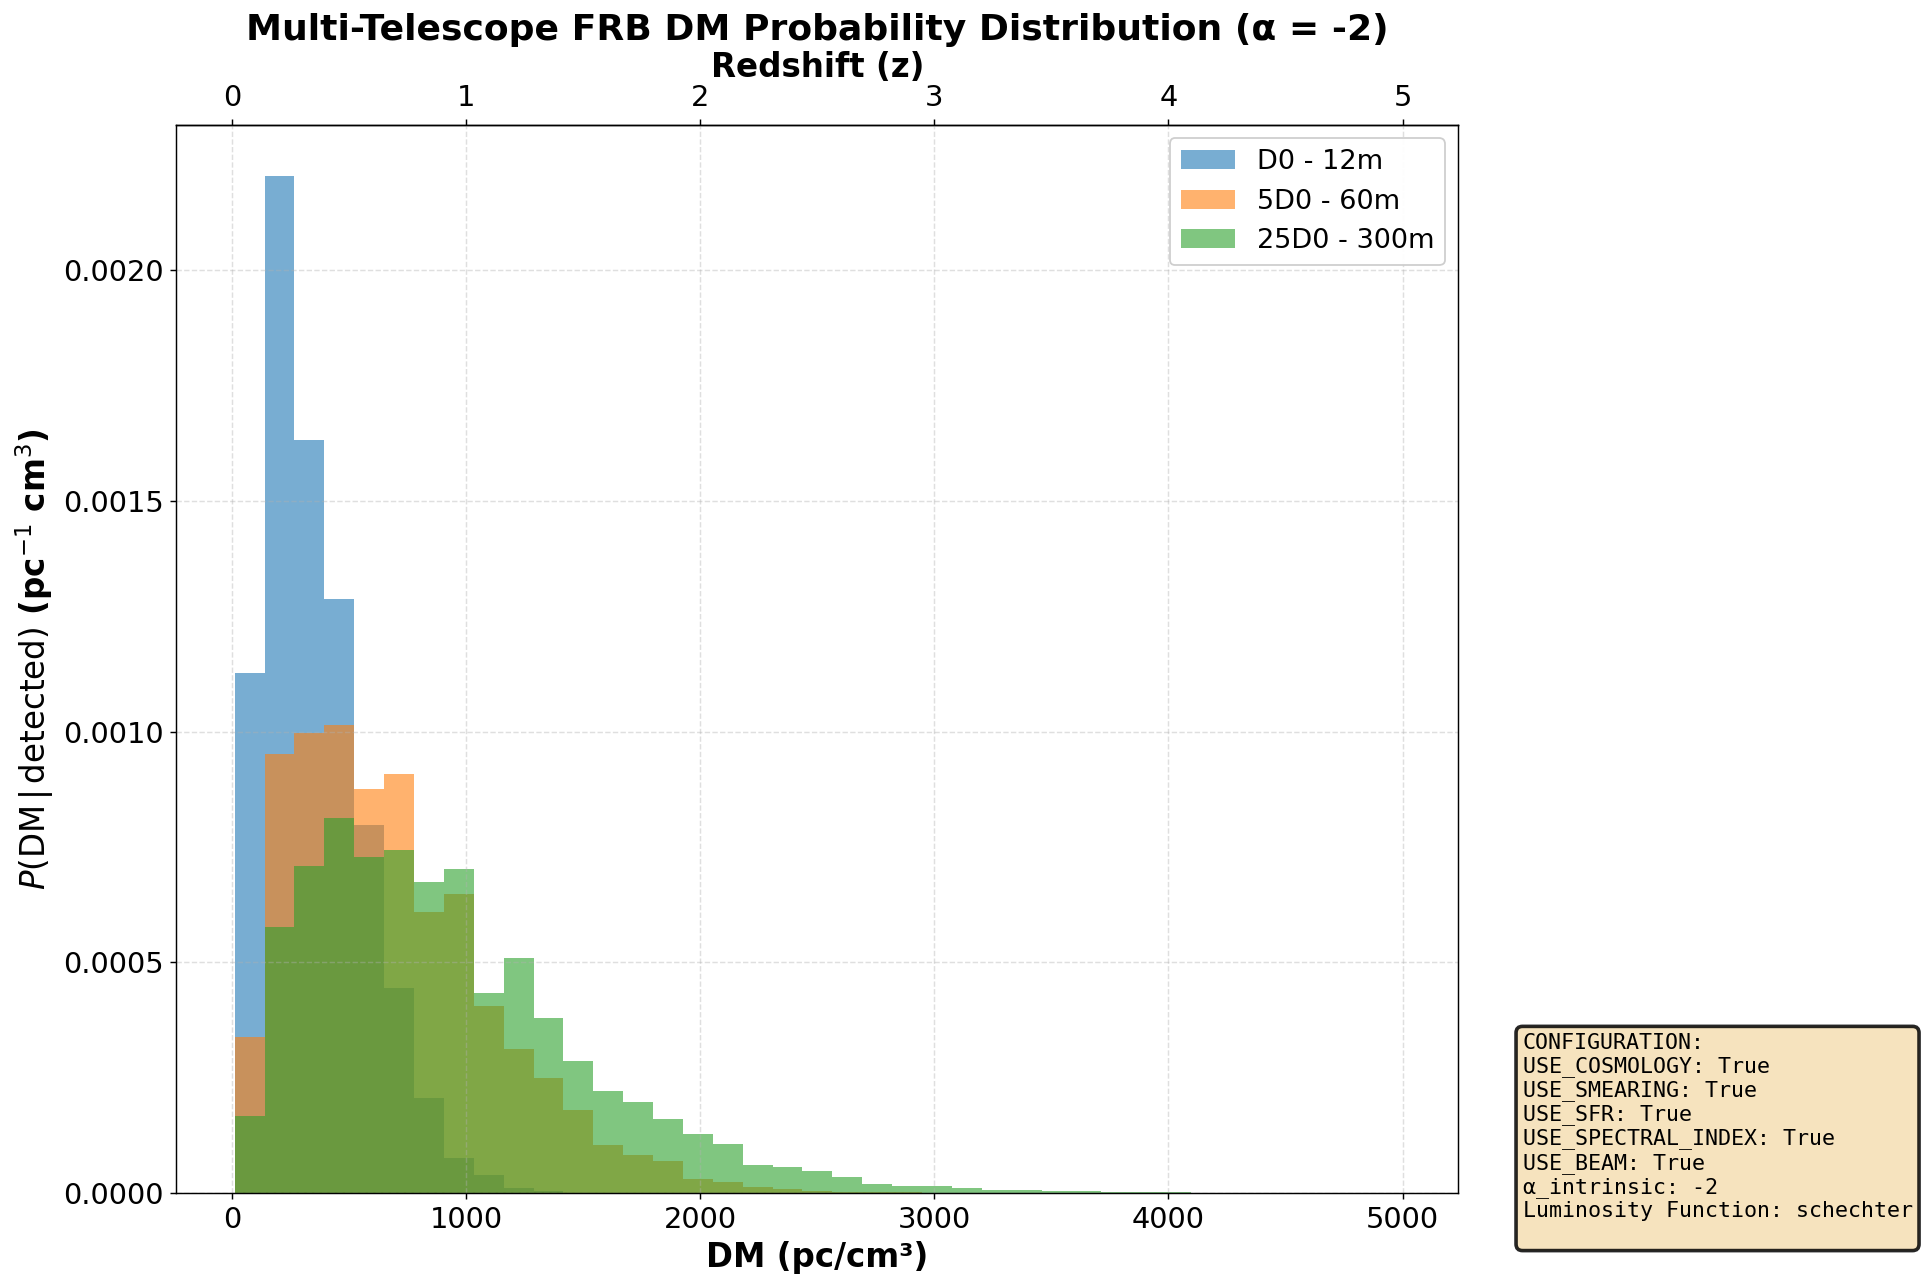

MULTI-TELESCOPE COMPARISON COMPLETE


In [12]:
fig, ax = plt.subplots(figsize=(15, 10), dpi=130)

# Find global DM range
dm_min = min([1000*r[0]['z'] for r in [all_results[k] for k in all_results if len(all_results[k]) > 0]])
dm_max = max([1000*r[-1]['z'] for r in [all_results[k] for k in all_results if len(all_results[k]) > 0]])
common_bins = np.linspace(dm_min, dm_max, 40)

# Plot histograms for each telescope
for tel_key in ['d0', '5d0', '25d0']:
    if tel_key in all_results and len(all_results[tel_key]) > 0:
        results = all_results[tel_key]
        DMs = np.array([r['DM'] for r in results])
        pops = np.array([r['n_total_population'] for r in results])
        
        # Create histogram as a Probability Density Function (PDF)
        # density=True ensures the integral over the histogram = 1.0 (P(DM|detected))
        ax.hist(DMs, bins=common_bins, weights=pops, density=True, alpha=0.6,
                label=labels_tel[tel_key], color=colors_tel[tel_key], linewidth=1.5)

# Create secondary x-axis for redshift (z)
ax2 = ax.secondary_xaxis('top', functions=(lambda x: x/1000, lambda x: x*1000))
ax2.set_xlabel('Redshift (z)', fontsize=18, fontweight='bold')
ax2.tick_params(axis='x', labelsize=16)

# Set labels and title
ax.set_xlabel('DM (pc/cm³)', fontsize=18, fontweight='bold')
ax.set_ylabel(r'$P(\mathrm{DM}\,|\,\mathrm{detected})$ (pc$^{-1}$ cm$^3$)', fontsize=18, fontweight='bold')
title = f'Multi-Telescope FRB DM Probability Distribution (α = {alpha_intrinsic})' if USE_SPECTRAL_INDEX else 'Multi-Telescope FRB DM Probability Distribution'
ax.set_title(title, fontsize=20, fontweight='bold')

# Increase tick label sizes
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# Add grid for both x and y
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)

# Increase legend font size
ax.legend(fontsize=15, loc='upper right', framealpha=0.95)

# Create configuration text box
config_text = (
    f"CONFIGURATION:\n"
    f"USE_COSMOLOGY: {USE_COSMOLOGY}\n"
    f"USE_SMEARING: {USE_SMEARING}\n"
    f"USE_SFR: {USE_SFR}\n"
    f"USE_SPECTRAL_INDEX: {USE_SPECTRAL_INDEX}\n"
     f"USE_BEAM: {USE_BEAM}\n"
)
if USE_SPECTRAL_INDEX:
    config_text += f"α_intrinsic: {alpha_intrinsic}\n"
config_text += f"Luminosity Function: {LUMINOSITY_FUNCTION}\n"

props = dict(boxstyle='round', facecolor='wheat', alpha=0.85, edgecolor='black', linewidth=2)
ax.text(1.05, 0.15, config_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
# plt.savefig('multi_telescope_normalized_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Plot created with PDF histograms and configuration box\n")
plt.show()

# Restore original parameters
D = D_orig
G0 = G0_orig
theta_max = theta_max_orig
params = params_orig

print(f"{'='*100}")
print("MULTI-TELESCOPE COMPARISON COMPLETE")
print(f"{'='*100}")

In [13]:
# ============================================================================
# LOAD REAL TELESCOPE DM DISTRIBUTIONS (READ FROM 'DM' COLUMN)
# ============================================================================

import pandas as pd
from pathlib import Path
import numpy as np

print("Loading real telescope DM data (from 'DM' column)...\n")

real_data_dir = Path("DM_distribution_real_data")

# Robust CSV loading function - specifically read DM column
def load_dm_data(file_path):
    """Load DM data from CSV file, extracting 'DM' column"""
    try:
        # Try to read CSV and extract 'DM' column
        data = pd.read_csv(file_path)
        if 'DM' in data.columns:
            dm_array = data['DM'].values
            dm_array = dm_array[~np.isnan(dm_array)]  # Remove NaN values
            return dm_array
        else:
            # If no 'DM' column, try first column
            print(f"    Warning: No 'DM' column found. Columns: {list(data.columns)}")
            dm_array = data.iloc[:, 0].values
            dm_array = dm_array[~np.isnan(dm_array)]
            return dm_array
    except:
        try:
            # Fallback: read with header=None and try different approaches
            data = pd.read_csv(file_path, header=None, on_bad_lines='skip')
            dm_array = data.values.flatten()
            dm_array = dm_array[~np.isnan(dm_array)]
            return dm_array
        except:
            try:
                # Last resort: numpy.loadtxt
                dm_array = np.loadtxt(file_path, delimiter=',', dtype=float)
                if dm_array.ndim == 1:
                    return dm_array
                else:
                    return dm_array.flatten()
            except:
                print(f"    Error: Could not parse {file_path}")
                return np.array([])

# Load real DM distributions
real_dm_data = {}
tel_files = {
    "askap_flyeye": "askap_flyeye.csv",
    "pks": "parkes.csv",
    "fast": "fast.csv",
    "askap_ics": "askap_ics.csv",
    "meerkat_cb": "meerkat_CB.csv",
    "meerkat_ib": "meerkat_IB.csv",
    "apertif": "apertif.csv",
    "dsa110": "dsa-110.csv",
}

for tel_name, file_name in tel_files.items():
    file_path = real_data_dir / file_name
    if file_path.exists():
        dm_array = load_dm_data(file_path)
        real_dm_data[tel_name] = dm_array
        if len(dm_array) > 0:
            print(f"✓ {tel_name:15s}: Loaded {len(dm_array):4d} DM values, range: [{np.min(dm_array):7.1f}, {np.max(dm_array):7.1f}]")
        else:
            print(f"✗ {tel_name:15s}: No data loaded")
    else:
        print(f"✗ {tel_name:15s}: File not found")

print(f"\n✓ Loaded {len(real_dm_data)} telescope datasets\n")

Loading real telescope DM data (from 'DM' column)...

✓ askap_flyeye   : Loaded   25 DM values, range: [  114.1,   991.7]
✓ pks            : Loaded   26 DM values, range: [  169.0,  2596.0]
✓ fast           : Loaded   10 DM values, range: [ 1187.7,  2765.2]
✓ askap_ics      : Loaded   43 DM values, range: [  206.0,  1785.3]
✓ meerkat_cb     : Loaded   18 DM values, range: [  433.6,  2660.4]
✓ meerkat_ib     : Loaded   15 DM values, range: [  433.6,  1990.0]
✓ apertif        : Loaded   24 DM values, range: [  246.5,  2778.0]
✓ dsa110         : Loaded   12 DM values, range: [  111.0,   706.7]

✓ Loaded 8 telescope datasets



/tmp/ipykernel_1727379/2974364794.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc='upper right')


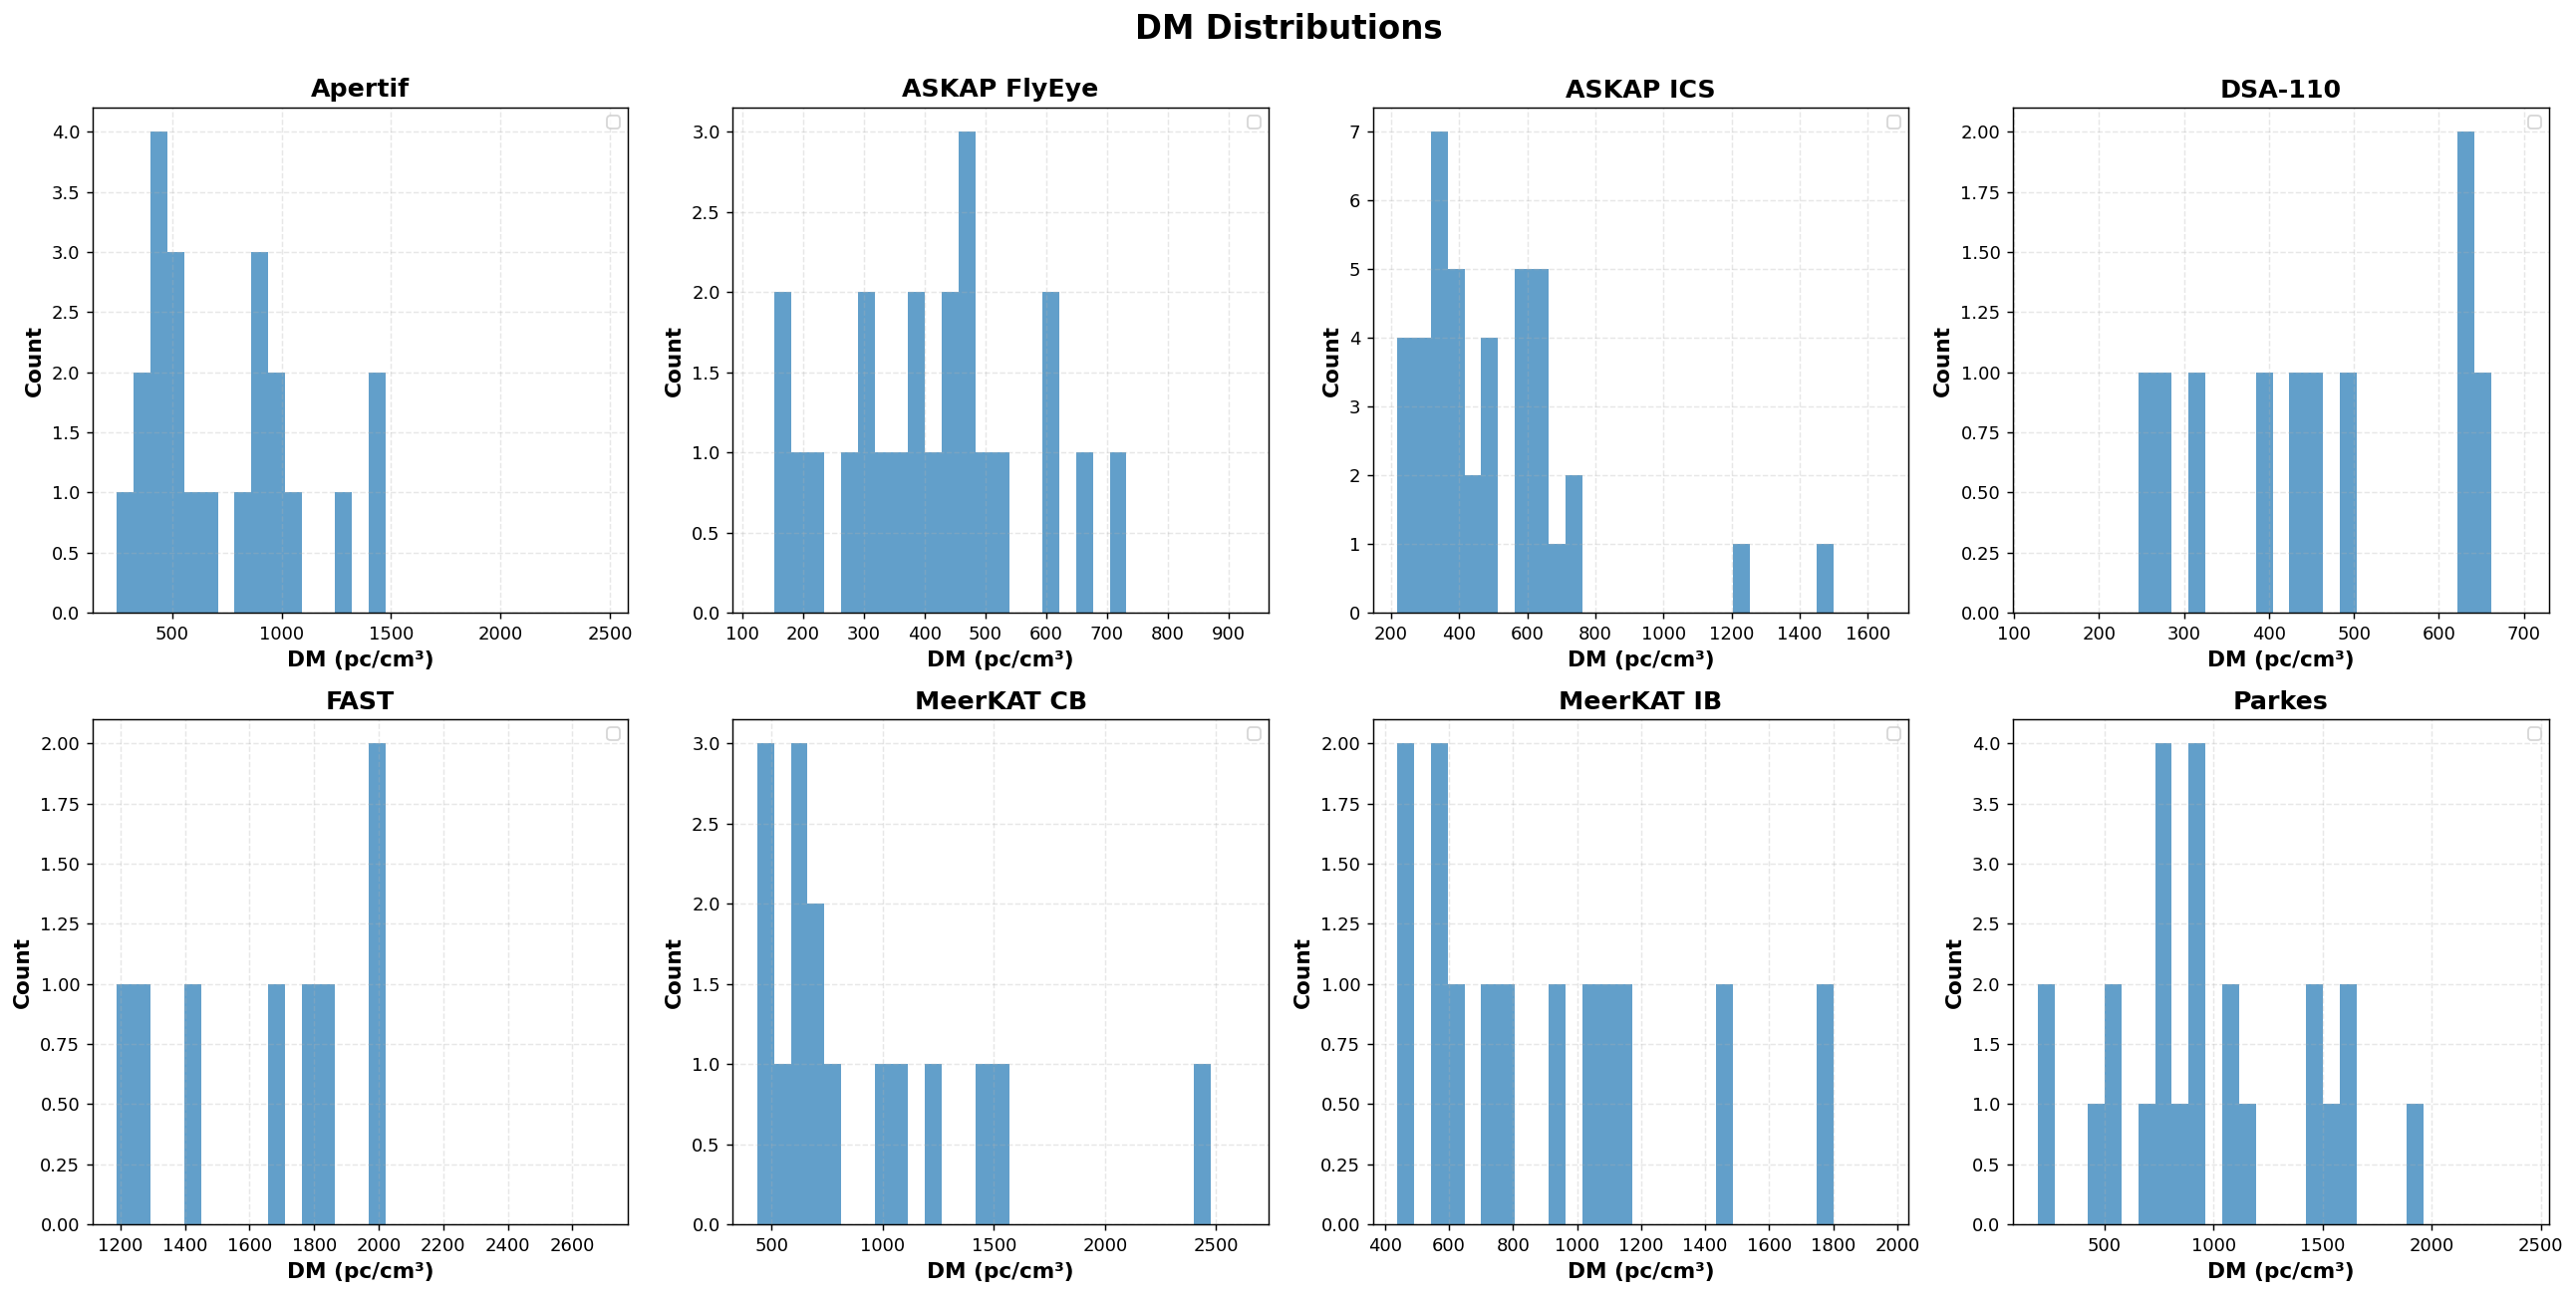

✓ Plot 1: All real telescopes individual subplots (stepfilled) created



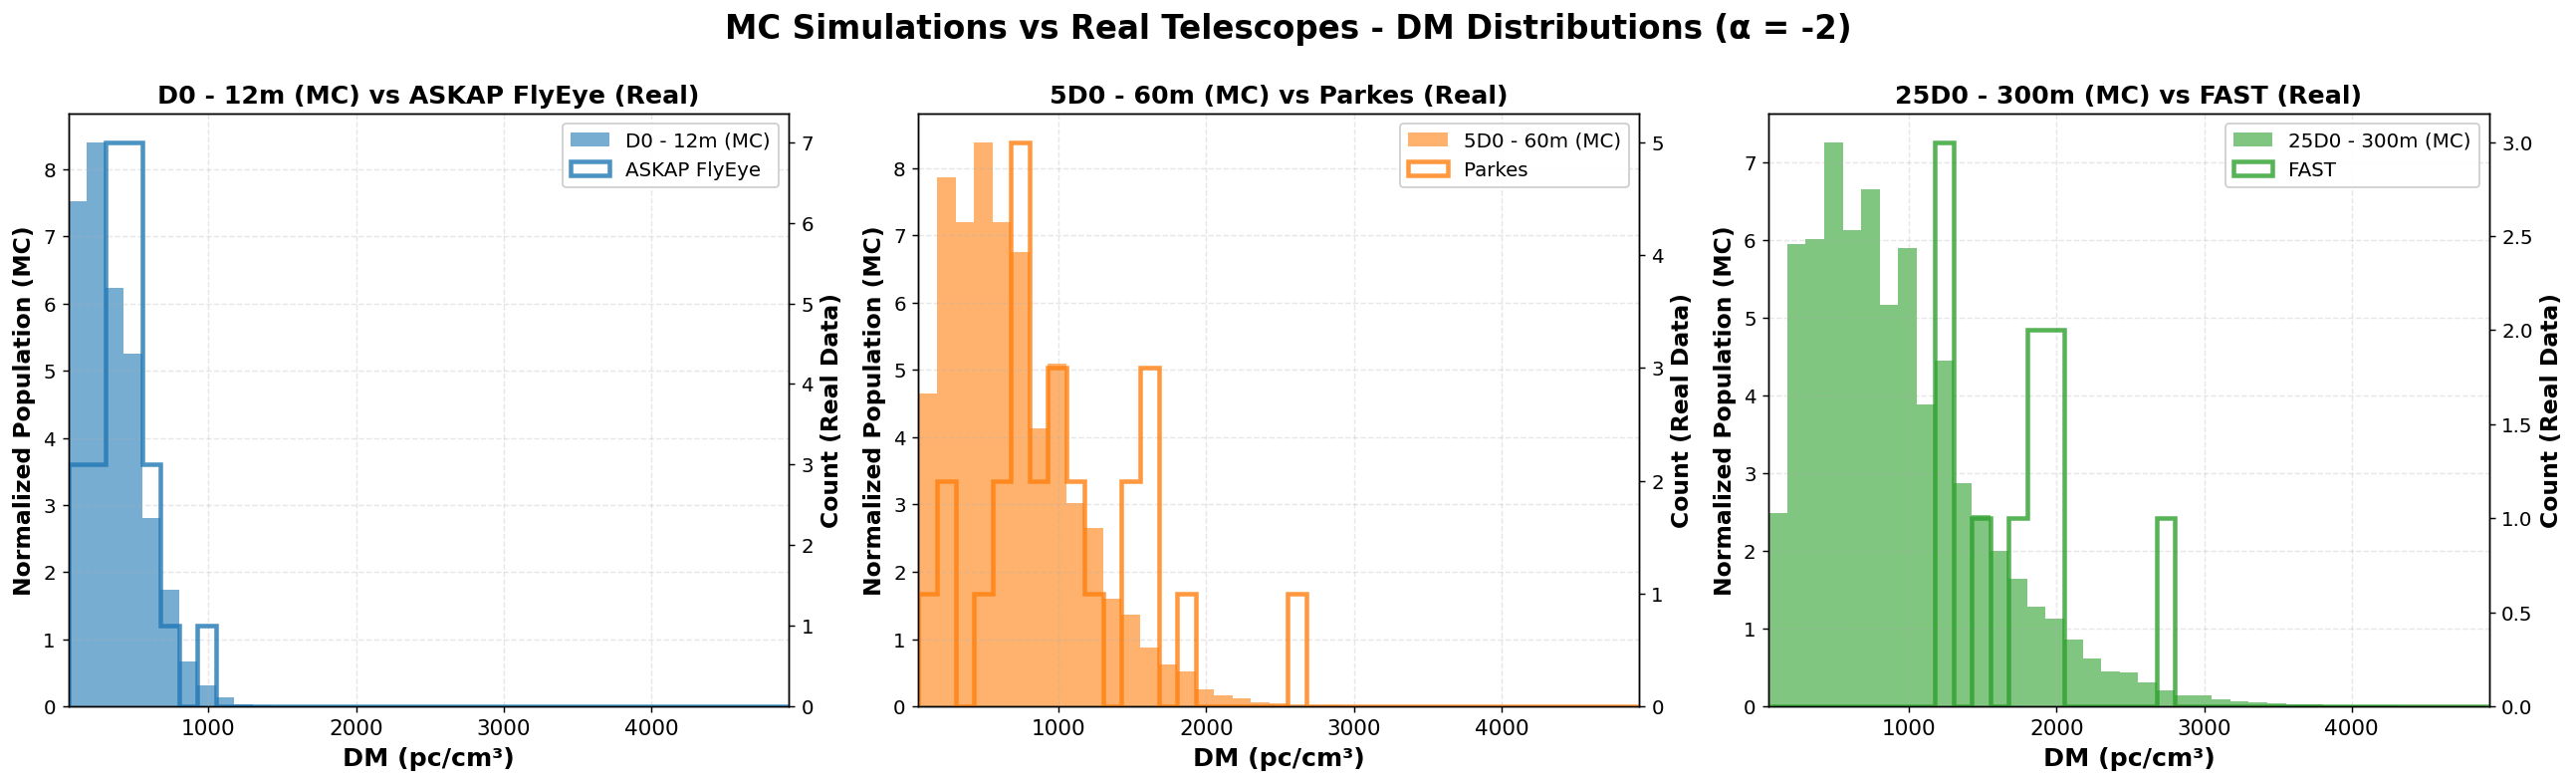

✓ Plot 2: Paired MC vs Real comparisons with unified x-axis scale created



In [14]:

# ============================================================================
# PLOT 1: ALL REAL TELESCOPES WITH STEP OUTLINE (SOLID LINE)
# ============================================================================



# Global DM range across all real telescopes
all_real_dms = []
for dm_array in real_dm_data.values():
    all_real_dms.extend(dm_array)

dm_min_real = np.percentile(all_real_dms, 1)
dm_max_real = np.percentile(all_real_dms, 99)
common_bins_real = np.linspace(dm_min_real, dm_max_real, 50)

# # Plot all real telescopes
# real_tel_colors = {
#     "askap_flyeye": "#1f77b4",      # blue
#     "pks": "#ff7f0e",               # orange
#     "fast": "#2ca02c",              # green
#     "askap_ics": "#d62728",         # red
#     "meerkat_cb": "#9467bd",        # purple
#     "meerkat_ib": "#8c564b",        # brown
#     "apertif": "#e377c2",           # pink
#     "dsa110": "#7f7f7f",            # gray
# }

real_tel_labels = {
    "askap_flyeye": "ASKAP FlyEye",
    "pks": "Parkes",
    "fast": "FAST",
    "askap_ics": "ASKAP ICS",
    "meerkat_cb": "MeerKAT CB",
    "meerkat_ib": "MeerKAT IB",
    "apertif": "Apertif",
    "dsa110": "DSA-110",
}

# ============================================================================
# PLOT 1: ALL REAL TELESCOPES - INDIVIDUAL SUBPLOTS WITH STEPFILLED HISTOGRAMS
# ============================================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10), dpi=130)
axes = axes.flatten()

# Global DM range for reference
all_real_dms = []
for dm_array in real_dm_data.values():
    all_real_dms.extend(dm_array)

dm_min_global = np.percentile(all_real_dms, 1)
dm_max_global = np.percentile(all_real_dms, 99)

# Plot each telescope in its own subplot
for idx, (tel_name, dm_array) in enumerate(sorted(real_dm_data.items())):
    ax = axes[idx]
    
    if len(dm_array) > 0:
        # Local bins for this telescope
        dm_min_local = np.percentile(dm_array, 1)
        dm_max_local = np.percentile(dm_array, 99)
        bins_local = np.linspace(dm_min_local, dm_max_local, 30)
        
        # Compute statistics
        median_dm = np.median(dm_array)
        mean_dm = np.mean(dm_array)
        std_dm = np.std(dm_array)
        
        # Plot histogram with stepfilled
        ax.hist(dm_array, bins=bins_local, alpha=0.7, 
                color='#1f77b4', linewidth=2, 
                histtype='stepfilled')
        
        # Add vertical line for median
        # ax.axvline(median_dm, color='red', linestyle='--', linewidth=2, alpha=0.8, label=f'Median: {median_dm:.1f}')
        
        # Labels and formatting
        ax.set_xlabel('DM (pc/cm³)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Count', fontsize=12, fontweight='bold')
        ax.set_title(real_tel_labels[tel_name], fontsize=14, fontweight='bold')
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.tick_params(axis='both', labelsize=10)
        
        # Add statistics box
        stats_text = f"Median: {median_dm:.1f}\nMean: {mean_dm:.1f}\nStd: {std_dm:.1f}"

plt.suptitle('DM Distributions', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Plot 1: All real telescopes individual subplots (stepfilled) created\n")

# ============================================================================
# PLOT 2: PAIRED COMPARISONS (MC vs REAL) - WITH UNIFIED X-AXIS SCALE
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=130)

# Calculate GLOBAL DM range across ALL pairs (before the loop)
all_dms_pairs = []
for mc_key, real_key, _ in [("d0", "askap_flyeye", colors_tel["d0"]),
                              ("5d0", "pks", colors_tel["5d0"]),
                              ("25d0", "fast", colors_tel["25d0"])]:
    if mc_key in all_results:
        mc_results = all_results[mc_key]
        mc_dms = np.array([r['DM'] for r in mc_results])
        all_dms_pairs.extend(mc_dms)
    if real_key in real_dm_data:
        all_dms_pairs.extend(real_dm_data[real_key])

dm_min_global = np.percentile(all_dms_pairs, 1)
dm_max_global = np.percentile(all_dms_pairs, 99)
common_bins_global = np.linspace(dm_min_global, dm_max_global, 40)

# Pairing configuration
pairs = [
    ("d0", "askap_flyeye", colors_tel["d0"]),
    ("5d0", "pks", colors_tel["5d0"]),
    ("25d0", "fast", colors_tel["25d0"]),
]

for ax_idx, (mc_key, real_key, color) in enumerate(pairs):
    ax_left = axes[ax_idx]
    ax_right = ax_left.twinx()
    
    # Get MC data
    if mc_key in all_results:
        mc_results = all_results[mc_key]
        mc_dms = np.array([r['DM'] for r in mc_results])
        mc_pops = np.array([r['n_total_population'] for r in mc_results])
    else:
        mc_dms = np.array([])
        mc_pops = np.array([])
    
    # Get real data
    real_dms = real_dm_data[real_key]
    
    # Calculate Kolmogorov-Smirnov test p-value
    if len(mc_dms) > 0 and len(real_dms) > 0:
        from scipy.stats import ks_2samp
        ks_stat, p_value = ks_2samp(mc_dms, real_dms)
    else:
        p_value = np.nan
    
    # Get max values for normalization
    mc_max = mc_pops.max() if len(mc_pops) > 0 else 1.0
    real_max = len(real_dms)
    
    # Plot MC histogram on LEFT axis (normalized population) - using GLOBAL bins
    if len(mc_dms) > 0:
        mc_pops_norm = mc_pops / mc_max
        ax_left.hist(mc_dms, bins=common_bins_global, weights=mc_pops_norm, alpha=0.6, 
                label=f'{labels_tel[mc_key]} (MC)', color=color, linewidth=1.5, histtype='stepfilled')
    
    # Plot real data on RIGHT axis (count) - using GLOBAL bins
    real_counts, _ = np.histogram(real_dms, bins=common_bins_global)
    ax_right.hist(real_dms, bins=common_bins_global, alpha=0.8, 
            label=real_tel_labels[real_key], color=color, 
            linewidth=2.5, histtype='step', linestyle='-', edgecolor=color)
    
    # Set the same x-axis limits for all subplots
    ax_left.set_xlim(dm_min_global, dm_max_global)
    
    # LEFT axis labels and formatting
    ax_left.set_xlabel('DM (pc/cm³)', fontsize=14, fontweight='bold')
    ax_left.set_ylabel('Normalized Population (MC)', fontsize=13, fontweight='bold')
    ax_left.tick_params(axis='y', labelsize=11)
    ax_left.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    
    # RIGHT axis labels and formatting
    ax_right.set_ylabel('Count (Real Data)', fontsize=13, fontweight='bold')
    ax_right.tick_params(axis='y', labelsize=11)
    
    # Title
    title_str = f'{labels_tel[mc_key]} (MC) vs {real_tel_labels[real_key]} (Real)'
    ax_left.set_title(title_str, fontsize=14, fontweight='bold')
    ax_left.tick_params(axis='x', labelsize=12)
    
    # Combined legend from both axes
    lines_left, labels_left = ax_left.get_legend_handles_labels()
    lines_right, labels_right = ax_right.get_legend_handles_labels()
    ax_left.legend(lines_left + lines_right, labels_left + labels_right, 
                  fontsize=11, loc='upper right', framealpha=0.95)

plt.suptitle(f'MC Simulations vs Real Telescopes - DM Distributions (α = {alpha_intrinsic})', 
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✓ Plot 2: Paired MC vs Real comparisons with unified x-axis scale created\n")

In [15]:
# import pickle
# out_path = "mc_all_results_cos_std.pkl"
# # out_path = "mc_all_results_cos_sch.pkl"
# # out_path = "mc_all_results_cos_sfr_sch.pkl"

# # out_path = "mc_all_results_cos_sfr_sch_smear.pkl"
# # out_path = "mc_all_results_alpha_minus_2.pkl"
# with open(out_path, "wb") as f:
#     pickle.dump(all_results, f)
# print("Saved MC pickle to", out_path)

Beam off vs Beam on

In [16]:
# ============================================================================
# COMPARE BEAM RESPONSE ON vs OFF (6 HISTOGRAMS: 3 telescopes × 2 scenarios)
# ============================================================================

print("\n" + "="*100)
print("COMPARING BEAM RESPONSE: ON vs OFF")
print("="*100 + "\n")

# Store results for beam ON and OFF
beam_results = {'on': {}, 'off': {}}

# Define once for the Euclidean branch
H0_km_s_Mpc = cosmo.H0.value if hasattr(cosmo, "H0") else 70.0
DH_Mpc = 299792.458 / H0_km_s_Mpc

for beam_mode in ['on', 'off']:
    print(f"\n{'='*60}")
    print(f"BEAM RESPONSE: {beam_mode.upper()}")
    print(f"{'='*60}\n")
    
    # Loop through all telescopes
    for tel_key in ["d0", "5d0", "25d0"]:
        print(f"  Telescope: {labels_tel[tel_key]}")
        
        # Update telescope parameters
        params = TELESCOPE_PARAMS[tel_key]
        D = params["D"]
        G0 = np.pi * D * D / 4 * eta / 2.0 / k * 1e-26
        theta_max = 2 * 1.22 * c / D / nu_min
        
        # Recalculate area for this telescope
        fwhm_rad = 1.22 * (c / nu_min) / D
        fwhm_deg = fwhm_rad * (180 / np.pi)
        r_deg = 2.0 * fwhm_deg
        area_tel = np.pi * (r_deg)**2
        
        # Independent seed for repeatability
        np.random.seed(42)
        
        # Re-compute L_min_by_z for this telescope
        L_min_by_z_new = {}
        nu0 = nu_cen
        
        for z in z_array_opt:
            if USE_COSMOLOGY:
                dl = cosmo.luminosity_distance(z).value * 1000.0
            else:
                dl = (DH_Mpc * z) * 1000.0
            
            G_max = gaussian_beam_gain(nu0, G0, 0, D, 3.0e8)
            S_min = SNR_threshold * (Trec + Tsky) / (G_max * np.sqrt(BW * t_obs * Np))
            
            if USE_SPECTRAL_INDEX:
                z_factor = (1 + z)**(-1 - alpha_intrinsic)
            else:
                z_factor = 1.0  # FIXED: Was (1+z)**(-1), now 1.0
            
            L_min = S_min * (dl**2) * z_factor
            L_min_by_z_new[z] = np.clip(L_min, L_MIN_SCH, L_MAX_SCH)
        
        sampler_cache.clear()
        
        # Run simulation for this telescope and beam mode
        results_tel = []
        _INNER_COEFF_CONST_new = (D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
        S_SNR_CONST = np.sqrt(BW_comp * t_obs * Np) / (Trec + Tsky)
        
        if USE_SPECTRAL_INDEX:
            nu_scaling = (nu_array / nu0)**alpha_intrinsic
        else:
            nu_scaling = np.ones_like(nu_array)  # FIXED: Was (nu_array / nu0), now np.ones_like(nu_array)
        
        for z_idx, z in enumerate(z_array_opt):
            zmin = z - 0.5 * dz
            zmax = z + 0.5 * dz
            L_min_z = L_min_by_z_new[z]
            
            if LUMINOSITY_FUNCTION.lower() == "std":
                if L_min_z > L_std:
                    break
            else:
                if L_min_z > 8.952e15:
                    break
            
            if LUMINOSITY_FUNCTION.lower() == "std":
                truncated_sampler = std_sampler(L_std)
            else:
                if L_min_z not in sampler_cache:
                    sampler_cache[L_min_z] = create_truncated_schechter_sampler(
                        L_min_z, L_MAX_SCH, L_STAR, ALPHA_SCH
                    )
                truncated_sampler = sampler_cache[L_min_z]
            
            DM = 1000 * z
            wi_z = 0.001 * (1 + z)
            BW_chan_MHz = BW_chan / 1e6
            nu_cen_GHz = nu_cen / 1e9
            
            if USE_SMEARING:
                w_DM = 8.3e-6 * DM * BW_chan_MHz / (nu_cen_GHz**3)
                w_scatter_comp = (
                    1.9e-7 * (DM**1.5) * (1 + (DM**3) * 3.55e-5) * 3 * freq_powers_scatter * 1e-3
                )
                w_scatter = np.sqrt(np.sum(w_scatter_comp**2) / len(w_scatter_comp))
                w_sampling = params["tsamp"] * 1e-3
            else:
                w_DM = 0.0
                w_scatter = 0.0
                w_sampling = 0.0
            
            w_obs_factor = np.sqrt(wi_z**2 + w_DM**2 + w_scatter**2 + w_sampling**2)
            
            if USE_COSMOLOGY:
                dl = cosmo.luminosity_distance(z).value * 1000.0
            else:
                dl = (DH_Mpc * z) * 1000.0
            
            if USE_SPECTRAL_INDEX:
                z_factor = (1 + z)**(-1 - alpha_intrinsic)
            else:
                z_factor = 1.0  # FIXED
            
            theta_hp = np.sqrt(np.log(2) / (_INNER_COEFF_CONST_new * nu0**2))
            
            n_generated = 0
            n_detected = 0
            detected_luminosities = []
            detected_snrs = []
            max_iterations = 1000000
            
            while n_detected < TARGET_DETECTIONS and n_generated < max_iterations:
                n_generated += 1
                
                # KEY CHANGE: Beam response ON/OFF
                if beam_mode == 'on':
                    theta_frb = theta_max * np.sqrt(np.random.random())
                else:  # beam_mode == 'off'
                    theta_frb = 0.0
                
                if theta_frb > 4.0 * theta_hp:
                    continue
                
                lum = float(truncated_sampler(np.random.uniform(0, 1)))
                S0_frb = (lum / (dl**2 * z_factor)) * (wi_z / w_obs_factor)
                S_nu = S0_frb * nu_scaling
                
                G_nu = G0 * np.exp(-(_INNER_COEFF_CONST_new * theta_frb**2) * nu_array**2)
                
                snr_spectrum = S_nu * G_nu * S_SNR_CONST
                snr_coherent = np.sum(snr_spectrum) / np.sqrt(n_comp)
                
                if snr_coherent > SNR_threshold:
                    n_detected += 1
                    detected_luminosities.append(lum)
                    detected_snrs.append(snr_coherent)
            
            if n_detected == TARGET_DETECTIONS:
                detection_rate = n_detected / n_generated
                
                if LUMINOSITY_FUNCTION.lower() == "std":
                    N_ratio = 1.0 if L_std >= L_min_z else 0.0
                else:
                    L_grid_full = np.logspace(10, 16, 5000)
                    phi_grid_full = schechter_function(L_grid_full, L_STAR, ALPHA_SCH)
                    cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0)
                    cdf_full /= cdf_full[-1]
                    cdf_interp = interp1d(L_grid_full, cdf_full, kind="linear")
                    N_ratio = 1.0 - cdf_interp(L_min_z)
                
                if USE_COSMOLOGY:
                    dt = (cosmo.age(zmin).value - cosmo.age(zmax).value) * 1e9
                    dvol = (
                        cosmo.comoving_volume(zmax).value - cosmo.comoving_volume(zmin).value
                    ) * (area_tel / (4.0 * np.pi * ((180.0 / np.pi)**2)))
                else:
                    r_Mpc = DH_Mpc * z
                    dr_Mpc = DH_Mpc * dz
                    area_sr = area_tel * (np.pi / 180.0)**2
                    dvol = (r_Mpc**2) * dr_Mpc * area_sr
                    dr_m = dr_Mpc * 3.0857e22
                    dt = dr_m / c / (3600.0 * 24.0 * 365.0)
                
                if USE_SFR:
                    psi = 0.015 * ((1 + z)**2.7) / (1 + ((1 + z) / 2.9)**5.6)
                else:
                    psi = 0.015
                
                nfrb_sfr = psi * dvol * dt * fscale
                n_total_population = detection_rate * N_ratio * nfrb_sfr
                
                results_tel.append({
                    "z": z,
                    "DM": DM,
                    "n_total_population": n_total_population
                })
        
        beam_results[beam_mode][tel_key] = results_tel

print("\n" + "="*100)
print("BEAM RESPONSE COMPARISON COMPLETE")
print("="*100)


COMPARING BEAM RESPONSE: ON vs OFF


BEAM RESPONSE: ON

  Telescope: D0 - 12m


/tmp/ipykernel_1727379/4221973470.py:12: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf = cumtrapz(phi_grid, L_grid, initial=0)
/tmp/ipykernel_1727379/4048166979.py:165: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0)


  Telescope: 5D0 - 60m
  Telescope: 25D0 - 300m

BEAM RESPONSE: OFF

  Telescope: D0 - 12m
  Telescope: 5D0 - 60m
  Telescope: 25D0 - 300m

BEAM RESPONSE COMPARISON COMPLETE


Bam response off or on


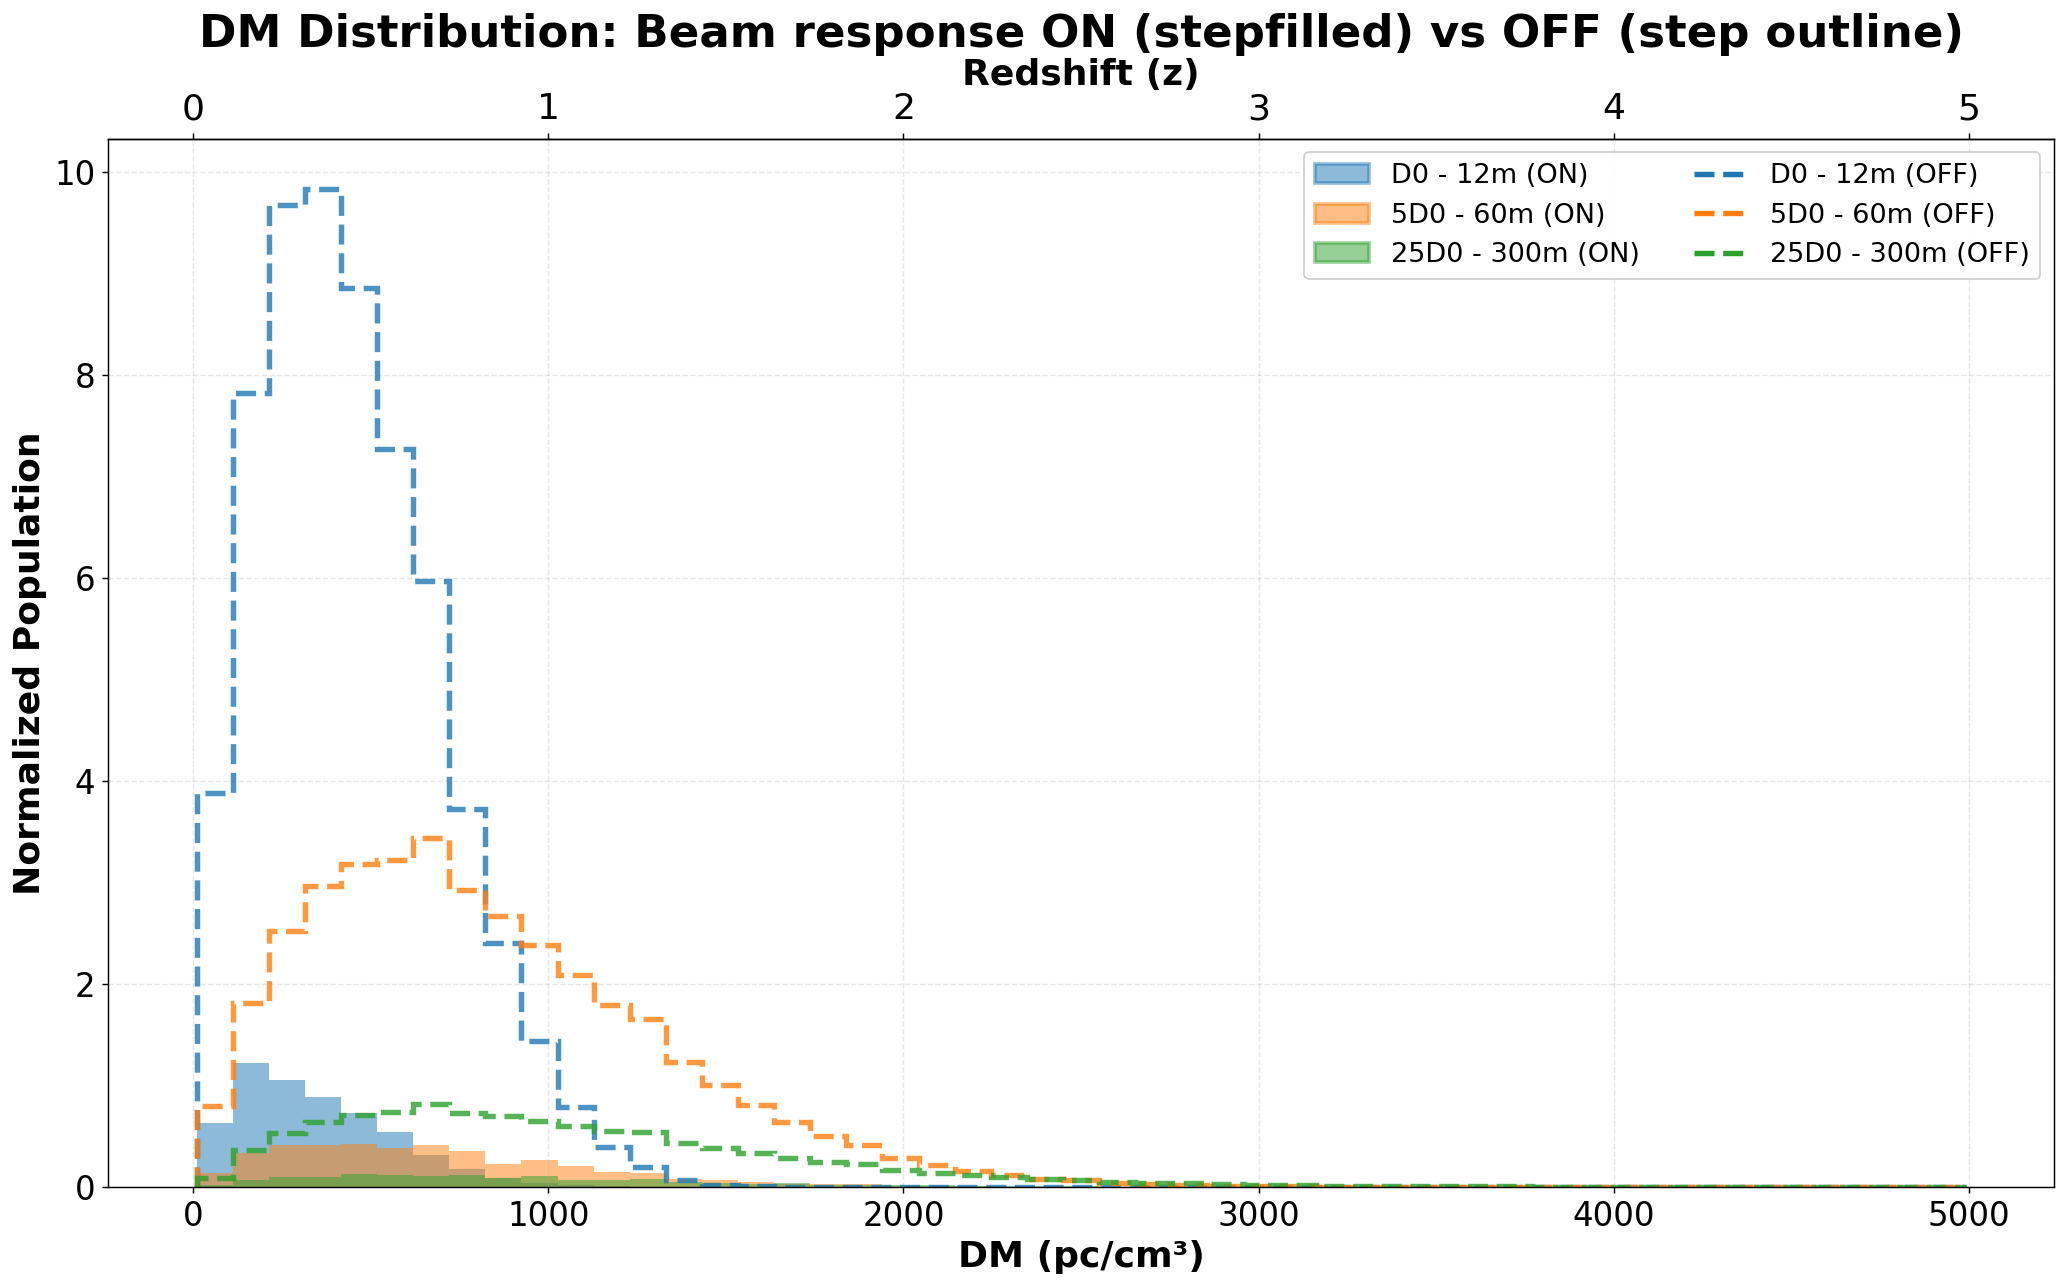


✓ Combined single-plot beam response comparison generated
   Filled histograms (stepfilled) = Beam ON
   Dashed outline (step) = Beam OFF



In [17]:
# ============================================================================
# COMBINED PLOT: ALL 3 TELESCOPES + BEAM ON/OFF (SINGLE PLOT)
# ============================================================================

fig, ax = plt.subplots(figsize=(16, 10), dpi=130)

# Find global DM range across all telescopes and beam modes
all_dms = []
for beam_mode in ['on', 'off']:
    for tel_key in ['d0', '5d0', '25d0']:
        all_dms.extend([1000*r['z'] for r in beam_results[beam_mode][tel_key]])

dm_min = min(all_dms)
dm_max = max(all_dms)
common_bins = np.linspace(dm_min, dm_max, 50)

# Get global max across all telescopes and beam modes
all_pops = []
for beam_mode in ['on', 'off']:
    for tel_key in ['d0', '5d0', '25d0']:
        pops = np.array([r['n_total_population'] for r in beam_results[beam_mode][tel_key]])
        all_pops.extend(pops)

global_max_all = max(all_pops)

# Plot for each telescope and beam mode
for tel_key in ['d0', '5d0', '25d0']:
    # BEAM ON - stepfilled histogram
    DMs_on = np.array([r['DM'] for r in beam_results['on'][tel_key]])
    pops_on = np.array([r['n_total_population'] for r in beam_results['on'][tel_key]])
    pops_normalized_on = pops_on / global_max_all
    pops_normalized_on = pops_on / global_max_all
    ax.hist(DMs_on, bins=common_bins, weights=pops_normalized_on, alpha=0.5, 
            label=f'{labels_tel[tel_key]} (Beam ON)', color=colors_tel[tel_key], 
            linewidth=2, histtype='stepfilled')
    
    # BEAM OFF - step histogram (outline only)
    DMs_off = np.array([r['DM'] for r in beam_results['off'][tel_key]])
    pops_off = np.array([r['n_total_population'] for r in beam_results['off'][tel_key]])
    pops_normalized_off = pops_off / global_max_all
    
    ax.hist(DMs_off, bins=common_bins, weights=pops_normalized_off, alpha=0.8,
            label=f'{labels_tel[tel_key]} (Beam OFF)', color=colors_tel[tel_key], 
            linewidth=3, histtype='step', linestyle='--')

# Secondary x-axis
ax2 = ax.secondary_xaxis('top', functions=(lambda x: x/1000, lambda x: x*1000))
ax2.set_xlabel('Redshift (z)', fontsize=20, fontweight='bold')
ax2.tick_params(axis='x', labelsize=20)

ax.set_xlabel('DM (pc/cm³)', fontsize=20, fontweight='bold')
ax.set_ylabel('Normalized Population', fontsize=20, fontweight='bold')
ax.set_title('DM Distribution: Beam response ON (stepfilled) vs OFF (step outline)', 
             fontsize=25, fontweight='bold')
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(fontsize=12, loc='upper right', framealpha=0.95)
import matplotlib.patches as mpatches

legend_handles = []
legend_labels = []

# Left column: ON modes
for tel_key in ['d0', '5d0', '25d0']:
    handle = mpatches.Patch(facecolor=colors_tel[tel_key], alpha=0.5, 
                           edgecolor=colors_tel[tel_key], linewidth=2)
    legend_handles.append(handle)
    legend_labels.append(f'{labels_tel[tel_key]} (ON)')

# Right column: OFF modes
for tel_key in ['d0', '5d0', '25d0']:
    from matplotlib.lines import Line2D
    handle = Line2D([0], [0], color=colors_tel[tel_key], linewidth=3, linestyle='--')
    legend_handles.append(handle)
    legend_labels.append(f'{labels_tel[tel_key]} (OFF)')

ax.legend(handles=legend_handles, labels=legend_labels, fontsize=15, 
         loc='upper right', framealpha=0.95, ncol=2)


plt.tight_layout()
plt.show()

print("\n✓ Combined single-plot beam response comparison generated")
print("   Filled histograms (stepfilled) = Beam ON")
print("   Dashed outline (step) = Beam OFF\n")

In [18]:
# Extract median DM from beam_results (cell 18)
import numpy as np

print("="*80)
print("MEDIAN DM FROM BEAM RESPONSE DATA (CELL 18)")
print("="*80)

results_table = []

for beam_mode in ['on', 'off']:
    for tel_key in ['d0', '5d0', '25d0']:
        if beam_mode in beam_results and tel_key in beam_results[beam_mode]:
            res = beam_results[beam_mode][tel_key]
            
            if len(res) > 0:
                DMs = np.array([r['DM'] for r in res])
                pops = np.array([r['n_total_population'] for r in res])
                
                # Sort by DM and compute weighted median
                sorted_idx = np.argsort(DMs)
                DMs_sorted = DMs[sorted_idx]
                pops_sorted = pops[sorted_idx]
                cumsum = np.cumsum(pops_sorted)
                cumsum_norm = cumsum / cumsum[-1]
                median_idx = np.searchsorted(cumsum_norm, 0.5)
                median_DM = DMs_sorted[median_idx] if median_idx < len(DMs_sorted) else DMs_sorted[-1]
                
                results_table.append({
                    'Beam': beam_mode.upper(),
                    'Telescope': labels_tel[tel_key],
                    'Median_DM': median_DM,
                    'Median_z': median_DM / 1000.0,
                    'N_bins': len(res),
                    'DM_min': DMs.min(),
                    'DM_max': DMs.max()
                })

# Display results in organized format
print("\n" + "="*80)
print("BEAM ON RESULTS:")
print("="*80)
for row in results_table:
    if row['Beam'] == 'ON':
        print(f"{row['Telescope']:15s}: Median DM = {row['Median_DM']:7.1f} pc/cm³ (z = {row['Median_z']:.3f})")

print("\n" + "="*80)
print("BEAM OFF RESULTS:")
print("="*80)
for row in results_table:
    if row['Beam'] == 'OFF':
        print(f"{row['Telescope']:15s}: Median DM = {row['Median_DM']:7.1f} pc/cm³ (z = {row['Median_z']:.3f})")

# Comparison
print("\n" + "="*80)
print("BEAM ON vs BEAM OFF COMPARISON:")
print("="*80)
for tel_key in ['d0', '5d0', '25d0']:
    on_data = [r for r in results_table if r['Beam'] == 'ON' and tel_key in r['Telescope'].lower()]
    off_data = [r for r in results_table if r['Beam'] == 'OFF' and tel_key in r['Telescope'].lower()]
    
    if on_data and off_data:
        on_dm = on_data[0]['Median_DM']
        off_dm = off_data[0]['Median_DM']
        diff = on_dm - off_dm
        pct = (diff / off_dm * 100) if off_dm != 0 else 0
        
        print(f"\n{on_data[0]['Telescope']}:")
        print(f"  Beam ON:  {on_dm:7.1f} pc/cm³")
        print(f"  Beam OFF: {off_dm:7.1f} pc/cm³")
        print(f"  Δ DM: {diff:+7.1f} pc/cm³ ({pct:+6.2f}%)")

MEDIAN DM FROM BEAM RESPONSE DATA (CELL 18)

BEAM ON RESULTS:
D0 - 12m       : Median DM =   310.0 pc/cm³ (z = 0.310)
5D0 - 60m      : Median DM =   610.0 pc/cm³ (z = 0.610)
25D0 - 300m    : Median DM =   800.0 pc/cm³ (z = 0.800)

BEAM OFF RESULTS:
D0 - 12m       : Median DM =   410.0 pc/cm³ (z = 0.410)
5D0 - 60m      : Median DM =   750.0 pc/cm³ (z = 0.750)
25D0 - 300m    : Median DM =   920.0 pc/cm³ (z = 0.920)

BEAM ON vs BEAM OFF COMPARISON:

D0 - 12m:
  Beam ON:    310.0 pc/cm³
  Beam OFF:   410.0 pc/cm³
  Δ DM:  -100.0 pc/cm³ (-24.39%)

5D0 - 60m:
  Beam ON:    610.0 pc/cm³
  Beam OFF:   750.0 pc/cm³
  Δ DM:  -140.0 pc/cm³ (-18.67%)

25D0 - 300m:
  Beam ON:    800.0 pc/cm³
  Beam OFF:   920.0 pc/cm³
  Δ DM:  -120.0 pc/cm³ (-13.04%)


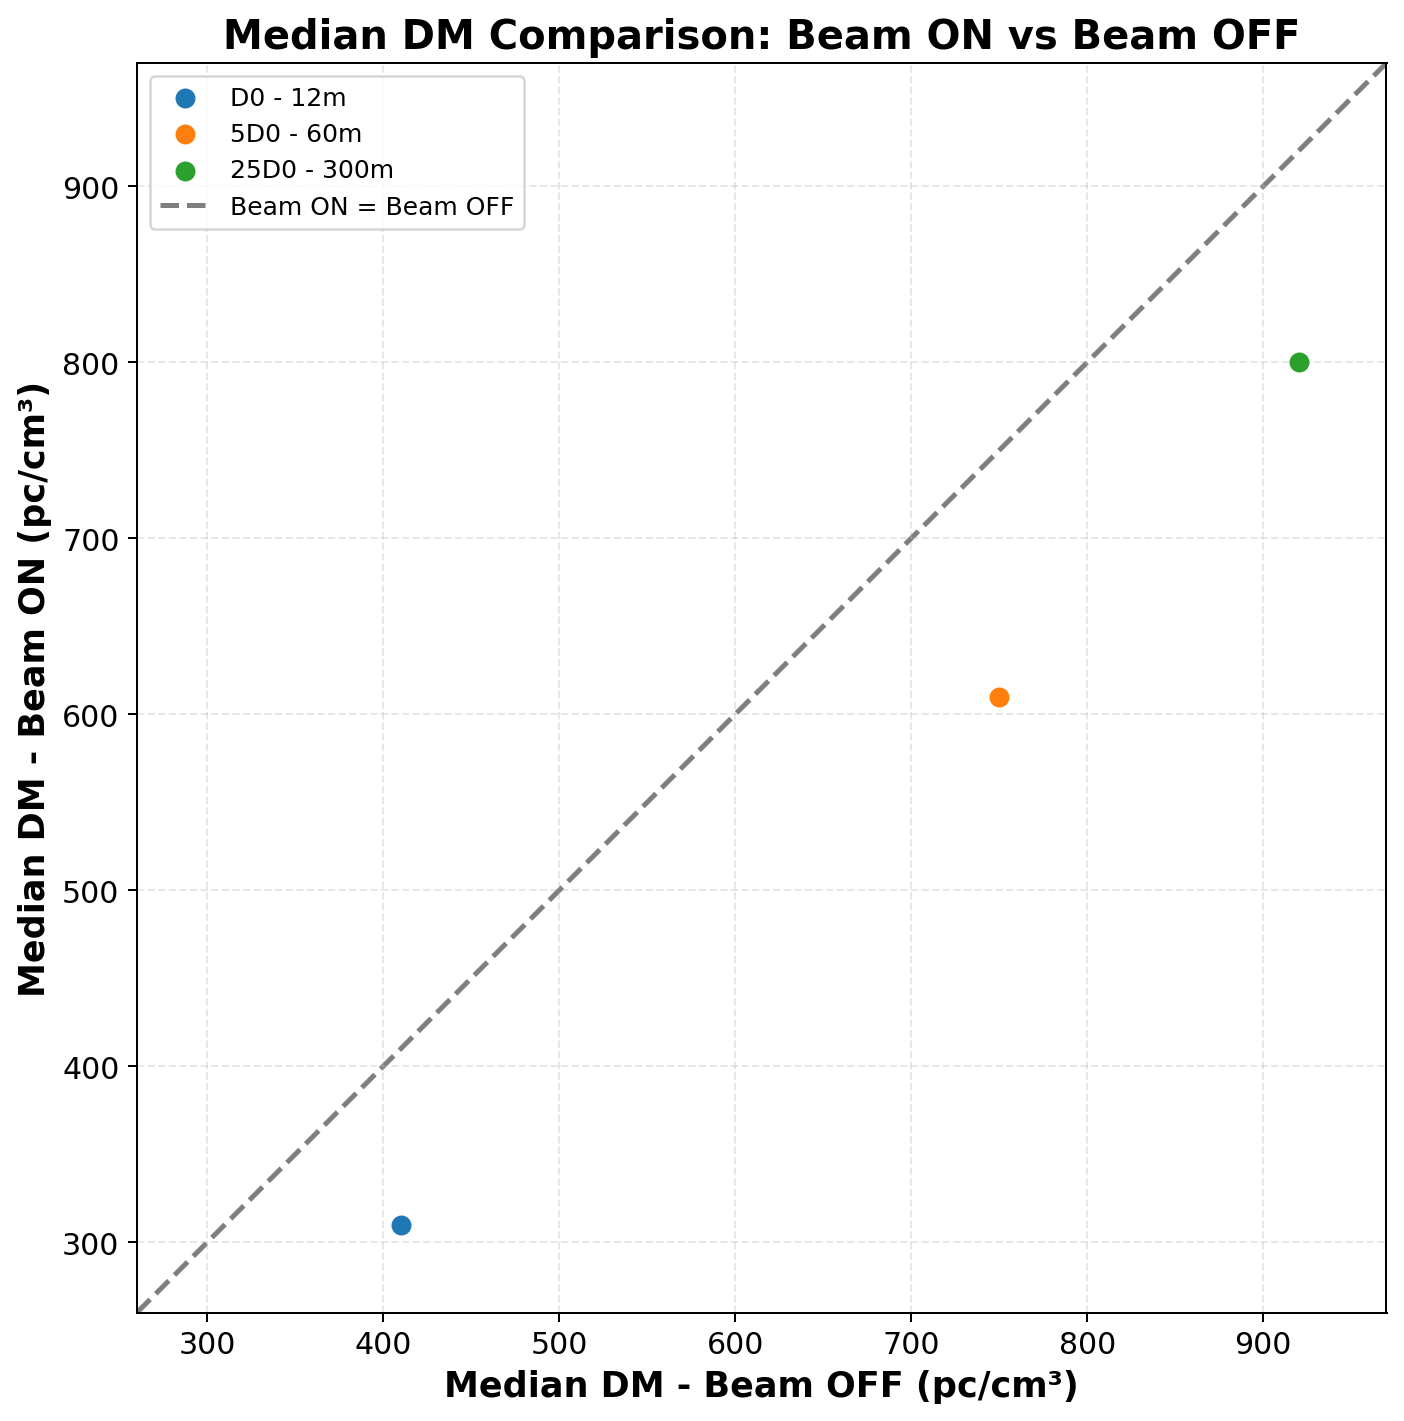


NUMERICAL SUMMARY:

D0 - 12m:
  Beam OFF (x-axis): 410.0 pc/cm³
  Beam ON (y-axis):  310.0 pc/cm³
  Δ DM (ON - OFF):   -100.0 pc/cm³
  % Difference:      -24.39%

5D0 - 60m:
  Beam OFF (x-axis): 750.0 pc/cm³
  Beam ON (y-axis):  610.0 pc/cm³
  Δ DM (ON - OFF):   -140.0 pc/cm³
  % Difference:      -18.67%

25D0 - 300m:
  Beam OFF (x-axis): 920.0 pc/cm³
  Beam ON (y-axis):  800.0 pc/cm³
  Δ DM (ON - OFF):   -120.0 pc/cm³
  % Difference:      -13.04%


In [19]:
# ============================================================================
# SCATTER PLOT: MEDIAN DM - BEAM ON vs BEAM OFF
# ============================================================================

fig, ax = plt.subplots(figsize=(8, 8), dpi=180)

# Extract data for plotting
x_data = []  # Beam OFF median DM
y_data = []  # Beam ON median DM
labels_plot = []

for tel_key in ['d0', '5d0', '25d0']:
    on_data = [r for r in results_table if r['Beam'] == 'ON' and tel_key in r['Telescope'].lower()]
    off_data = [r for r in results_table if r['Beam'] == 'OFF' and tel_key in r['Telescope'].lower()]
    
    if on_data and off_data:
        x_data.append(off_data[0]['Median_DM'])
        y_data.append(on_data[0]['Median_DM'])
        labels_plot.append(labels_tel[tel_key])

# Convert to arrays
x_data = np.array(x_data)
y_data = np.array(y_data)

# Plot scatter points
for i, (x, y, label) in enumerate(zip(x_data, y_data, labels_plot)):
    ax.scatter(x, y, s=30, color=colors_tel[['d0', '5d0', '25d0'][i]]
               , linewidth=2.5, zorder=3, label=label)
    # # Add text labels
    # ax.text(x, y + 15, label, fontsize=12, fontweight='bold', 
    #        ha='center', va='bottom')

# Add diagonal reference line (where Beam ON = Beam OFF)
lim_min = min(x_data.min(), y_data.min()) - 50
lim_max = max(x_data.max(), y_data.max()) + 50
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=2, 
       label='Beam ON = Beam OFF', alpha=0.5, zorder=1)

# Labels and formatting
ax.set_xlabel('Median DM - Beam OFF (pc/cm³)', fontsize=14, fontweight='bold')
ax.set_ylabel('Median DM - Beam ON (pc/cm³)', fontsize=14, fontweight='bold')
ax.set_title('Median DM Comparison: Beam ON vs Beam OFF', fontsize=16, fontweight='bold')

# Set axis limits with padding
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.legend ()
# Make axes equal
ax.set_aspect('equal')

# Grid and ticks
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

# Print numerical comparison
print("\n" + "="*80)
print("NUMERICAL SUMMARY:")
print("="*80)
for i, tel_key in enumerate(['d0', '5d0', '25d0']):
    print(f"\n{labels_tel[tel_key]}:")
    print(f"  Beam OFF (x-axis): {x_data[i]:.1f} pc/cm³")
    print(f"  Beam ON (y-axis):  {y_data[i]:.1f} pc/cm³")
    print(f"  Δ DM (ON - OFF):   {y_data[i] - x_data[i]:+.1f} pc/cm³")
    pct_diff = ((y_data[i] - x_data[i]) / x_data[i] * 100) if x_data[i] != 0 else 0
    print(f"  % Difference:      {pct_diff:+.2f}%")